# Laboratorio #4 — Fundamentos de Aprendizaje por Refuerzo y Gymnasium

**CC3092 Deep Learning y Sistemas Inteligentes**

Este notebook contiene (1) la investigación de los fundamentos de RL, (2) la
investigación de la librería Gymnasium y (3) un módulo exploratorio con la API
de Gymnasium: agente aleatorio en dos entornos y una política simple no
aprendida para CartPole-v1.

## 1. Fundamentos del aprendizaje por refuerzo

Investigación de los conceptos fundamentales. Fuentes citadas por tema.

**Referencias usadas en esta sección**

- [SB] R. Sutton y A. Barto, *Reinforcement Learning: An Introduction*, 2.ª ed.,
  MIT Press, 2018. <http://incompleteideas.net/book/the-book-2nd.html>
- [GYM] Gymnasium documentation — *Introduction / Basic Usage*.
  <https://gymnasium.farama.org/introduction/basic_usage/>
- [WD] C. Watkins y P. Dayan, "Q-learning", *Machine Learning* 8, 279–292, 1992.
  <https://doi.org/10.1007/BF00992698>

### ¿Qué es el aprendizaje por refuerzo y en qué se diferencia del supervisado y del no supervisado?

El aprendizaje por refuerzo (RL) es el problema de aprender **qué hacer** —cómo
mapear situaciones a acciones— para maximizar una señal escalar de recompensa
acumulada a lo largo del tiempo. El aprendiz no recibe ejemplos de la acción
correcta: debe descubrirla probando y observando la recompensa que produce
[SB, cap. 1].

- **vs. supervisado:** el supervisado aprende de un conjunto de ejemplos
  etiquetados `(entrada, salida correcta)` provistos por un supervisor externo;
  su objetivo es generalizar a entradas no vistas. En RL no hay etiqueta de la
  acción óptima, solo una recompensa que evalúa la acción tomada (feedback
  *evaluativo*, no *instructivo*), y las decisiones afectan qué datos se
  observarán después [SB, §1.1].
- **vs. no supervisado:** el no supervisado busca estructura oculta en datos sin
  etiqueta (clustering, densidad). RL tampoco usa etiquetas, pero su meta no es
  encontrar estructura sino **maximizar recompensa**. Es un tercer paradigma
  [SB, §1.1].
- Rasgos propios de RL: compromiso **exploración vs. explotación**, feedback
  **retardado** (una acción puede afectar recompensas muchos pasos después) y
  datos **no i.i.d.** que dependen de la política del agente.

### Componentes principales de un problema de RL

- **Agente:** el que aprende y decide. Observa el estado, elige acciones y
  recibe recompensas [GYM].
- **Entorno (environment):** todo lo externo al agente; recibe la acción y
  devuelve el siguiente estado y la recompensa. En Gymnasium es el objeto `Env`
  con `reset()` y `step()` [GYM].
- **Estado (state) / observación:** descripción de la situación actual usada por
  el agente para decidir. La *observación* puede ser parcial respecto al estado
  interno real del entorno.
- **Acción (action):** decisión del agente en cada paso; puede ser discreta
  (empujar izquierda/derecha) o continua (torque).
- **Recompensa (reward):** escalar `R_t` que emite el entorno tras cada acción;
  define **qué** se quiere lograr, no **cómo**. El objetivo del agente es
  maximizar el retorno `G_t = R_{t+1} + γR_{t+2} + γ²R_{t+3} + …` [SB, §3.1–3.3].
- **Política (policy) `π`:** la estrategia del agente, un mapeo de estados a
  acciones (`π(s)`) o a una distribución sobre acciones (`π(a|s)`). Es lo que se
  aprende [SB, §3.1].

### ¿Qué es un Proceso de Decisión de Markov (MDP)?

Un MDP es la formalización matemática de la toma de decisiones secuencial donde
las acciones influyen en recompensas inmediatas y en estados futuros. Cumple la
**propiedad de Markov**: el futuro depende solo del estado y acción actuales, no
de la historia completa [SB, cap. 3]. Un MDP finito es la tupla
`(S, A, P, R, γ)`:

- **`S` — estados:** conjunto de situaciones posibles del entorno.
- **`A` — acciones:** conjunto de decisiones disponibles (`A(s)` si depende del
  estado).
- **`P` — función de transición:** `P(s' | s, a)` = probabilidad de pasar a `s'`
  dado que en `s` se tomó `a`. Codifica la dinámica del entorno.
- **`R` — función de recompensa:** recompensa esperada `R(s, a, s')` (o
  `R(s, a)`) por esa transición.
- **`γ` — factor de descuento** (`0 ≤ γ ≤ 1`): pondera cuánto valen las
  recompensas futuras frente a las inmediatas. `γ→0` = agente miope; `γ→1` =
  agente previsor. Garantiza que el retorno sea finito en tareas continuas
  [SB, §3.3–3.4].

### Función de valor de estado `V(s)` y función de valor acción-estado `Q(s,a)`

- **`V^π(s)`** = retorno esperado si el agente **empieza en `s` y luego sigue la
  política `π`**: `V^π(s) = E_π[G_t | S_t = s]`. Mide "qué tan bueno" es un
  estado bajo `π` [SB, §3.5].
- **`Q^π(s,a)`** = retorno esperado si en `s` se toma la acción `a` (posiblemente
  distinta de `π(s)`) y **después** se sigue `π`:
  `Q^π(s,a) = E_π[G_t | S_t = s, A_t = a]`. Mide "qué tan buena" es una acción en
  un estado [SB, §3.5].
- **Relación entre ambas:** `V^π(s) = Σ_a π(a|s) Q^π(s,a)`.
- **Relación con la política óptima:** la política óptima `π*` maximiza el valor
  en todo estado. Sus funciones de valor `V*` y `Q*` satisfacen
  `V*(s) = max_a Q*(s,a)`, y una política óptima se obtiene actuando **greedy**
  sobre `Q*`: `π*(s) = argmax_a Q*(s,a)`. Conocer `Q*` basta para actuar
  óptimamente **sin modelo** del entorno; con solo `V*` se necesita `P` para
  mirar un paso adelante [SB, §3.6].

### Ecuación de Bellman

**Intuición:** el valor de un estado se puede escribir en términos del valor de
sus estados sucesores. "El valor de donde estoy = recompensa inmediata esperada
+ valor descontado de a dónde llego". Es una condición de **consistencia**
recursiva entre valores vecinos [SB, §3.5].

Ecuación de Bellman para `V^π`:

`V^π(s) = Σ_a π(a|s) Σ_{s'} P(s'|s,a) [ R(s,a,s') + γ V^π(s') ]`

Ecuación de **optimalidad** de Bellman (para `π*`):

`V*(s) = max_a Σ_{s'} P(s'|s,a) [ R(s,a,s') + γ V*(s') ]`

**Rol en el cálculo de las funciones de valor:** convierte el cálculo del valor
—que en principio es una suma infinita sobre trayectorias— en un sistema de
ecuaciones acopladas, una por estado. Los métodos de RL son esencialmente
formas de **resolver o aproximar** estas ecuaciones: programación dinámica
(barridos completos con el modelo), Monte Carlo (promedios de retornos
muestreados) y diferencia temporal / Q-Learning (actualizaciones incrementales
que empujan la estimación hacia el lado derecho de Bellman) [SB, cap. 4 y 6].

### Dilema exploración vs. explotación

Para maximizar recompensa el agente debe **explotar** lo que ya sabe que
funciona; pero para descubrir mejores acciones debe **explorar** alternativas
que parecen peores. Ninguna de las dos por sí sola tiene éxito, y explorar
cuesta recompensa a corto plazo [SB, §1.1, cap. 2]. Dos estrategias:

1. **ε-greedy:** con probabilidad `1−ε` se toma la acción greedy
   (`argmax_a Q(s,a)`), y con probabilidad `ε` una acción **uniforme al azar**.
   `ε` suele decaer con el tiempo (mucho explorar al inicio, casi puro explotar
   al final). Simple y muy usada; explora "a ciegas" sin distinguir entre la
   segunda mejor acción y la peor [SB, §2.2].
2. **Softmax / Boltzmann:** se muestrea la acción de una distribución
   `π(a|s) = exp(Q(s,a)/τ) / Σ_b exp(Q(s,b)/τ)`. La **temperatura `τ`** controla
   la aleatoriedad: `τ` alta → casi uniforme (mucha exploración); `τ` baja →
   casi greedy. A diferencia de ε-greedy, explora **proporcionalmente al valor
   estimado** (prueba más las acciones prometedoras) [SB, §2.3].

### Diferencias entre familias de métodos

- **Tareas episódicas vs. continuas:** las **episódicas** tienen un estado
  terminal que reinicia el problema (una partida, un intento de CartPole hasta
  caer); el retorno es una suma finita. Las **continuas** no terminan
  (control de un proceso 24/7); requieren `γ<1` (o recompensa media) para que el
  retorno sea finito [SB, §3.3–3.4]. En Gymnasium esto aparece como
  `terminated` (fin natural del episodio) vs. `truncated` (corte artificial por
  límite de tiempo).
- **On-policy vs. off-policy:** los métodos **on-policy** evalúan y mejoran la
  **misma** política que usan para generar los datos (p. ej. SARSA). Los
  **off-policy** aprenden sobre una política *objetivo* (normalmente la greedy /
  óptima) usando datos generados por otra política *de comportamiento* más
  exploratoria (p. ej. Q-Learning). Off-policy es más flexible (permite reusar
  datos, aprender de demostraciones) pero suele tener más varianza [SB, §5.5, 6.4–6.5].
- **Model-based vs. model-free:** **model-based** aprende o dispone de un modelo
  del entorno (`P` y `R`) y **planifica** con él (value/policy iteration, Dyna,
  MCTS); es más eficiente en muestras pero sensible a errores del modelo.
  **Model-free** (Q-Learning, SARSA, policy gradients) aprende valores o política
  **directamente de la experiencia**, sin modelo; más simple y robusto, pero
  necesita más interacción [SB, cap. 8].

### Q-Learning: actualización de valores y papel de `α` y `γ`

Q-Learning [WD] es un método **model-free, off-policy** de diferencia temporal
que aprende `Q*` directamente. Tras observar `(s, a, r, s')` actualiza:

`Q(s,a) ← Q(s,a) + α [ r + γ · max_{a'} Q(s',a') − Q(s,a) ]`

El término entre corchetes es el **error de diferencia temporal (TD error)**: la
diferencia entre la estimación actual `Q(s,a)` y un objetivo mejor informado
`r + γ·max_{a'} Q(s',a')` (recompensa real observada + mejor valor futuro
estimado). La actualización mueve `Q(s,a)` una fracción `α` hacia ese objetivo.
Es **off-policy** porque el objetivo usa `max_{a'}` (política greedy) aunque la
acción `a` se haya elegido explorando (p. ej. ε-greedy).

- **Tasa de aprendizaje `α` (`0<α≤1`):** tamaño del paso. `α` alta → aprende
  rápido pero las estimaciones oscilan con el ruido de las transiciones; `α`
  baja → convergencia lenta pero estable. La convergencia teórica a `Q*` exige
  que `α` decaiga adecuadamente y que todo par `(s,a)` se visite infinitamente
  [WD; SB, §6.5].
- **Factor de descuento `γ` (`0≤γ<1`):** cuánto pesa `max_{a'} Q(s',a')`, es
  decir el futuro. `γ` cerca de 0 hace al agente miope (solo busca `r`
  inmediata); `γ` cerca de 1 lo hace planificar a largo plazo, pero ralentiza la
  propagación de la señal y puede inestabilizar el aprendizaje con aproximación
  de funciones [SB, §3.4, 6.5].

## 2. La librería Gymnasium

Investigación documentada con celdas de código que ilustran cada punto.

**Referencias**

- [GYM] Gymnasium documentation. <https://gymnasium.farama.org/>
- [GYM-ENV] *Gymnasium — Env API*. <https://gymnasium.farama.org/api/env/>
- [GYM-SPACES] *Gymnasium — Spaces*. <https://gymnasium.farama.org/api/spaces/>
- [GYM-WRAP] *Gymnasium — Wrappers*. <https://gymnasium.farama.org/api/wrappers/>
- [FARAMA] Farama Foundation, "Announcing the Farama Foundation", 2022.
  <https://farama.org/Announcing-The-Farama-Foundation>

### ¿Qué es Gymnasium y qué problema resuelve? ¿Cómo se relaciona con OpenAI Gym?

Gymnasium es una librería de Python que define una **API estándar para entornos
de aprendizaje por refuerzo** y provee una colección de entornos de referencia
que la implementan [GYM]. El problema que resuelve es de **interoperabilidad**:
antes, cada entorno y cada algoritmo tenían su propia interfaz; con la API
común (`reset`, `step`, `render`, espacios de observación/acción autodescritos)
un mismo agente puede entrenarse en cualquier entorno compatible sin cambiar el
código de interacción, y los resultados son comparables entre trabajos.

Gymnasium es el **fork mantenido de OpenAI Gym**. OpenAI dejó de mantener Gym en
2021 y en 2022 la **Farama Foundation** tomó el desarrollo bajo el nombre
Gymnasium [FARAMA]. Es un reemplazo directo (`import gymnasium as gym`) con
algunos cambios de API respecto a las últimas versiones de Gym, sobre todo que
`step()` devuelve **cinco** valores separando `terminated` y `truncated` (antes
un único `done`), y `reset()` devuelve `(observation, info)` y acepta `seed=`.

### Instalación y verificación de versión

In [1]:
import gymnasium as gym
print("gymnasium:", gym.__version__)

gymnasium: 1.3.0


### Estructura básica de un entorno (`Env`)

| Método | Recibe | Devuelve | Para qué |
|---|---|---|---|
| `reset(seed=None, options=None)` | semilla opcional | `(observation, info)` | inicia un episodio nuevo y entrega la observación inicial |
| `step(action)` | una acción del `action_space` | `(observation, reward, terminated, truncated, info)` | avanza un paso de simulación aplicando la acción |
| `render()` | — | frame RGB / None (según `render_mode`) | produce una visualización del estado actual |
| `close()` | — | `None` | libera recursos (ventanas, procesos, archivos) |

La tupla de `step()` [GYM-ENV]:

- **`observation`** — nueva observación del entorno, elemento del `observation_space`.
- **`reward`** — recompensa escalar (`float`) obtenida por esa transición.
- **`terminated`** — `bool`; `True` si el episodio llegó a un **estado terminal
  del MDP** (meta alcanzada, poste caído, agente muerto). Aquí `γ` no debe
  descontar un valor futuro: no hay futuro.
- **`truncated`** — `bool`; `True` si el episodio se cortó por una condición
  **externa al MDP**, típicamente el límite de pasos (`TimeLimit`). El estado no
  es terminal; hay valor futuro que un algoritmo de bootstrapping sí debería
  considerar.
- **`info`** — `dict` con diagnósticos auxiliares (no se debe usar para
  aprender): recompensas parciales, métricas, etc.

El episodio termina cuando `terminated or truncated`.

In [2]:
env = gym.make("CartPole-v1")
obs, info = env.reset(seed=0)
print("obs inicial:", obs, "| info:", info)
obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
print("tras 1 step -> obs:", obs)
print("reward:", reward, "| terminated:", terminated, "| truncated:", truncated, "| info:", info)
env.close()

obs inicial: [ 0.01369617 -0.02302133 -0.04590265 -0.04834723] | info: {}
tras 1 step -> obs: [ 0.01323574  0.17272775 -0.04686959 -0.3551522 ]
reward: 1.0 | terminated: False | truncated: False | info: {}


### Espacios de observación y acción (`Spaces`)

Un `Space` describe el formato válido de observaciones/acciones y sabe
`sample()` (muestra aleatoria) y `contains(x)` (validación) [GYM-SPACES].

- **`Discrete(n, start=0)`** — un entero en `{start, …, start+n−1}`. Un solo
  valor categórico. Se usa para conjuntos finitos de acciones (izquierda/derecha)
  o de estados enumerados (la casilla en una grilla). Ej.: acción de CartPole-v1
  (`Discrete(2)`), observación de FrozenLake-v1 (`Discrete(16)`).
- **`Box(low, high, shape, dtype)`** — vector/tensor de reales (o enteros)
  acotado por `low`/`high` (pueden ser `±inf`) elemento a elemento. Se usa para
  magnitudes continuas: observaciones físicas (posición, velocidad, ángulo),
  imágenes (`Box(0, 255, (H,W,3), uint8)`), acciones continuas (torque). Ej.:
  observación de CartPole-v1 (`Box(4,)`), acción de Pendulum-v1 (`Box(1,)`).
- **`MultiDiscrete(nvec)`** — vector de enteros, cada componente `i` en
  `{0, …, nvec[i]−1}`; es un producto de varios `Discrete` independientes. Se usa
  cuando la acción/observación tiene **varias dimensiones categóricas
  simultáneas**: p. ej. un gamepad (`[cruceta(5), botónA(2), botónB(2)]`) o los
  controles del entorno Atari con `full_action_space` factorizado.

Otros: `MultiBinary`, `Tuple`, `Dict`, `Text`, `Sequence`, `Graph`.

In [3]:
from gymnasium.spaces import Discrete, Box, MultiDiscrete
import numpy as np

d = Discrete(4)
b = Box(low=-1.0, high=1.0, shape=(3,), dtype=np.float32)
m = MultiDiscrete([5, 2, 2])
for s in (d, b, m):
    x = s.sample()
    print(f"{str(s):32s} sample={x}  contains(sample)={s.contains(x)}")

Discrete(4)                      sample=2  contains(sample)=True
Box(-1.0, 1.0, (3,), float32)    sample=[ 0.25112543  0.9177533  -0.6421363 ]  contains(sample)=True
MultiDiscrete([5 2 2])           sample=[2 0 1]  contains(sample)=True


### Catálogo de entornos — 4 entornos de distintas familias

| Entorno (familia) | Objetivo | `observation_space` | `action_space` |
|---|---|---|---|
| **CartPole-v1** (Classic Control) | mantener un poste en equilibrio sobre un carro moviéndolo izq/der; +1 por paso, hasta 500 | `Box(4,)`: posición y velocidad del carro, ángulo y velocidad angular del poste | `Discrete(2)`: empujar izquierda / derecha |
| **MountainCar-v0** (Classic Control) | llevar un carro sin potencia a la cima de una colina acumulando impulso; −1 por paso hasta llegar (máx. 200) | `Box(2,)`: posición ∈[−1.2, 0.6] y velocidad ∈[−0.07, 0.07] | `Discrete(3)`: acelerar izq / no acelerar / acelerar der |
| **FrozenLake-v1** (Toy Text) | cruzar una grilla 4×4 helada del inicio a la meta sin caer en un agujero; +1 solo al llegar a la meta | `Discrete(16)`: índice de la casilla actual | `Discrete(4)`: mover izq / abajo / der / arriba (resbaladizo si `is_slippery=True`) |
| **LunarLander-v3** (Box2D) | aterrizar un módulo lunar suavemente sobre la plataforma; recompensa por acercarse/aterrizar, penaliza chocar y gastar combustible | `Box(8,)`: posición (x,y), velocidad (vx,vy), ángulo y vel. angular, 2 flags de contacto de patas | `Discrete(4)` (motor apagado / izq / principal / der) — o `Box(2,)` en la variante continua |

CartPole/MountainCar/FrozenLake vienen instalados con
`gymnasium[classic-control,toy-text]`; LunarLander requiere el extra `box2d`.

In [4]:
for name in ["CartPole-v1", "MountainCar-v0", "FrozenLake-v1"]:
    e = gym.make(name)
    print(f"{name:16s} obs={e.observation_space}  act={e.action_space}  "
          f"max_episode_steps={e.spec.max_episode_steps}")
    e.close()

CartPole-v1      obs=Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)  act=Discrete(2)  max_episode_steps=500
MountainCar-v0   obs=Box([-1.2  -0.07], [0.6  0.07], (2,), float32)  act=Discrete(3)  max_episode_steps=200
FrozenLake-v1    obs=Discrete(16)  act=Discrete(4)  max_episode_steps=100


### ¿Qué es un *wrapper*?

Un wrapper envuelve un `Env` y **modifica su comportamiento sin tocar el código
del entorno**, exponiendo la misma API `Env` (patrón decorador). Se apilan: al
hacer `gym.make("CartPole-v1")` el objeto ya viene envuelto en
`TimeLimit(OrderEnforcing(PassiveEnvChecker(CartPoleEnv)))` [GYM-WRAP]. Sirven
para transformar observaciones, acciones o recompensas, y para añadir
funcionalidad transversal. Ejemplos:

- **`TimeLimit`** — pone `truncated=True` al alcanzar `max_episode_steps`
  (500 en CartPole-v1), evitando episodios infinitos.
- **`RecordVideo`** — graba episodios a archivos `.mp4` para inspección.
- **`RecordEpisodeStatistics`** — agrega a `info` el retorno y la longitud de
  cada episodio al terminar.
- **Normalización** — `NormalizeObservation` / `NormalizeReward` mantienen media
  y varianza corrientes y estandarizan; `RescaleAction`, `ClipAction`,
  `FrameStackObservation`, `GrayscaleObservation`, `ResizeObservation` son otros
  comunes en visión/control.

In [5]:
from gymnasium.wrappers import TimeLimit

base = gym.make("CartPole-v1")
print("cadena de wrappers:", base)
short = TimeLimit(gym.make("CartPole-v1").unwrapped, max_episode_steps=10)
short.reset(seed=0)
steps = 0
while True:
    _, _, term, trunc, _ = short.step(short.action_space.sample())
    steps += 1
    if term or trunc:
        break
print(f"con TimeLimit(max=10): el episodio se cortó en {steps} pasos "
      f"(truncated={trunc}, terminated={term})")
base.close(); short.close()

cadena de wrappers: <TimeLimit<OrderEnforcing<PassiveEnvChecker<CartPoleEnv<CartPole-v1>>>>>
con TimeLimit(max=10): el episodio se cortó en 10 pasos (truncated=True, terminated=True)


## 3. Módulo de prueba: primeros pasos con Gymnasium

Módulo exploratorio. No se entrena ningún agente: el objetivo es practicar la
API y observar el comportamiento de agentes simples.

### 3.0. Setup

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from pathlib import Path

FIGS = Path("figs"); FIGS.mkdir(exist_ok=True)
RNG_SEED = 42
print("gymnasium:", gym.__version__)

gymnasium: 1.3.0


### 3.1. CartPole-v1: espacios de observación y acción

In [7]:
def describe_space(space):
    kind = type(space).__name__
    if isinstance(space, gym.spaces.Box):
        return (f"{kind}  shape={space.shape}  dtype={space.dtype}\n"
                f"      low  = {np.array2string(space.low,  precision=3)}\n"
                f"      high = {np.array2string(space.high, precision=3)}")
    if isinstance(space, gym.spaces.Discrete):
        return f"{kind}  n={space.n}  valores enteros en [{space.start}, {space.start + space.n - 1}]"
    return f"{kind}  {space}"


env = gym.make("CartPole-v1")
print("observation_space:", describe_space(env.observation_space))
print()
print("action_space     :", describe_space(env.action_space))
print()
print("Componentes de la observación: [pos. carro, vel. carro, ángulo poste (rad), vel. angular poste]")
print("Acciones: 0 = empujar a la izquierda, 1 = empujar a la derecha")
env.close()

observation_space: Box  shape=(4,)  dtype=float32
      low  = [-4.8     -inf -0.419   -inf]
      high = [4.8     inf 0.419   inf]

action_space     : Discrete  n=2  valores enteros en [0, 1]

Componentes de la observación: [pos. carro, vel. carro, ángulo poste (rad), vel. angular poste]
Acciones: 0 = empujar a la izquierda, 1 = empujar a la derecha


La observación es un `Box(4,)` de `float32`: la posición del carro está acotada a
±4.8 y el ángulo del poste a ±0.418 rad (±24°), mientras que las dos velocidades
son ilimitadas (`±inf`). La acción es `Discrete(2)`. El episodio termina
(`terminated`) si el poste pasa de ±12° o el carro se sale de ±2.4, y se trunca
(`truncated`) a los 500 pasos.

### 3.2. Agente aleatorio en CartPole-v1

In [8]:
def run_episodes(env, policy, n_episodes, seed=0, render=False):
    """Corre n episodios completos. policy(obs, env) -> action.
    Devuelve (steps_por_episodio, return_por_episodio)."""
    steps_hist, return_hist = [], []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done, steps, total = False, 0, 0.0
        while not done:
            action = policy(obs, env)
            obs, reward, terminated, truncated, _ = env.step(action)
            total += reward
            steps += 1
            done = terminated or truncated
        steps_hist.append(steps)
        return_hist.append(total)
    return np.array(steps_hist), np.array(return_hist)


def random_policy(obs, env):
    return env.action_space.sample()


N_EP = 20  # el enunciado pide >= 5; usamos 20 para una media más estable
env = gym.make("CartPole-v1")
cp_rand_steps, cp_rand_ret = run_episodes(env, random_policy, N_EP, seed=RNG_SEED)
env.close()

for i, (s, r) in enumerate(zip(cp_rand_steps, cp_rand_ret), 1):
    print(f"  episodio {i:2d}: pasos sobrevividos = {s:3d}   recompensa total (return) = {r:6.1f}")
print(f"\nCartPole-v1 / agente aleatorio ({N_EP} episodios): "
      f"return medio = {cp_rand_ret.mean():.1f} ± {cp_rand_ret.std():.1f}  "
      f"(min {cp_rand_ret.min():.0f}, max {cp_rand_ret.max():.0f})")

  episodio  1: pasos sobrevividos =  36   recompensa total (return) =   36.0
  episodio  2: pasos sobrevividos =  31   recompensa total (return) =   31.0
  episodio  3: pasos sobrevividos =  19   recompensa total (return) =   19.0
  episodio  4: pasos sobrevividos =  21   recompensa total (return) =   21.0
  episodio  5: pasos sobrevividos =  30   recompensa total (return) =   30.0
  episodio  6: pasos sobrevividos =  17   recompensa total (return) =   17.0
  episodio  7: pasos sobrevividos =  35   recompensa total (return) =   35.0
  episodio  8: pasos sobrevividos =  13   recompensa total (return) =   13.0
  episodio  9: pasos sobrevividos =  17   recompensa total (return) =   17.0
  episodio 10: pasos sobrevividos =  18   recompensa total (return) =   18.0
  episodio 11: pasos sobrevividos =  20   recompensa total (return) =   20.0
  episodio 12: pasos sobrevividos =  14   recompensa total (return) =   14.0
  episodio 13: pasos sobrevividos =  22   recompensa total (return) =   22.0

En CartPole-v1 la recompensa es +1 por paso, así que **el return de cada
episodio es igual a los pasos sobrevividos**. El agente aleatorio aguanta
típicamente entre 10 y 40 pasos antes de que el poste caiga: muy lejos de los
500 posibles.

### 3.3. Gráfica: recompensa total por episodio (CartPole-v1, agente aleatorio)

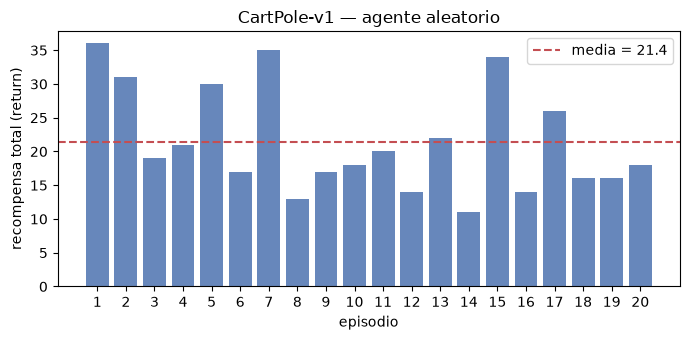

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.5))
eps = np.arange(1, N_EP + 1)
ax.bar(eps, cp_rand_ret, color="#4C72B0", alpha=0.85)
ax.axhline(cp_rand_ret.mean(), color="#C44E52", ls="--",
           label=f"media = {cp_rand_ret.mean():.1f}")
ax.set_xlabel("episodio"); ax.set_ylabel("recompensa total (return)")
ax.set_title("CartPole-v1 — agente aleatorio")
ax.set_xticks(eps); ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "cartpole_random.png", dpi=130)
plt.show()

### 3.4. Agente aleatorio en un segundo entorno discreto: FrozenLake-v1

In [10]:
# FrozenLake-v1: grilla 4x4, observación Discrete(16), acción Discrete(4),
# is_slippery=True (por defecto) -> el hielo desvía el movimiento de forma estocástica.
N_EP_FL = 50  # >= 5; más episodios para estimar una tasa de éxito con sentido

env = gym.make("FrozenLake-v1", is_slippery=True)
print("observation_space:", describe_space(env.observation_space))
print("action_space     :", describe_space(env.action_space), " (0=izq, 1=abajo, 2=der, 3=arriba)")

fl_rand_steps, fl_rand_ret = run_episodes(env, random_policy, N_EP_FL, seed=RNG_SEED)
env.close()

success = fl_rand_ret > 0  # en FrozenLake reward=1 solo si se alcanza la meta
print(f"\nFrozenLake-v1 / agente aleatorio ({N_EP_FL} episodios):")
print(f"  episodios que alcanzaron la meta: {success.sum()} / {N_EP_FL}  "
      f"(tasa de éxito = {success.mean()*100:.0f}%)")
print(f"  pasos por episodio: media = {fl_rand_steps.mean():.1f}  (min {fl_rand_steps.min()}, max {fl_rand_steps.max()})")
print(f"  return medio = {fl_rand_ret.mean():.3f}")

observation_space: Discrete  n=16  valores enteros en [0, 15]
action_space     : Discrete  n=4  valores enteros en [0, 3]  (0=izq, 1=abajo, 2=der, 3=arriba)

FrozenLake-v1 / agente aleatorio (50 episodios):
  episodios que alcanzaron la meta: 0 / 50  (tasa de éxito = 0%)
  pasos por episodio: media = 7.3  (min 2, max 20)
  return medio = 0.000


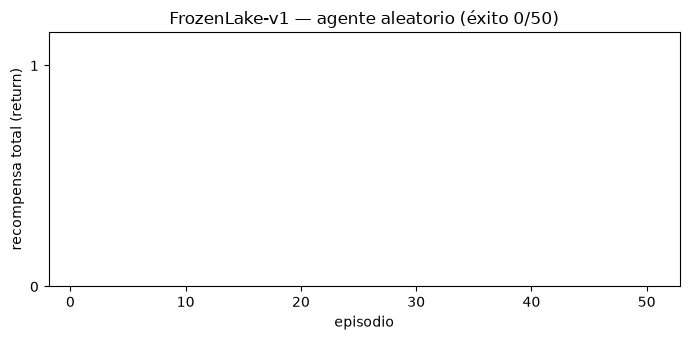

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.5))
eps = np.arange(1, N_EP_FL + 1)
colors = ["#55A868" if s else "#C44E52" for s in success]
ax.bar(eps, fl_rand_ret, color=colors)
ax.set_xlabel("episodio"); ax.set_ylabel("recompensa total (return)")
ax.set_title(f"FrozenLake-v1 — agente aleatorio (éxito {success.sum()}/{N_EP_FL})")
ax.set_yticks([0, 1]); ax.set_ylim(0, 1.15)
fig.tight_layout()
fig.savefig(FIGS / "frozenlake_random.png", dpi=130)
plt.show()

**¿Resuelve el agente aleatorio FrozenLake-v1?** Prácticamente no. La recompensa
es +1 **solo** si se llega a la meta y 0 en cualquier otro caso (incluido caer en
un agujero), sin ninguna señal intermedia que guíe. Con `is_slippery=True` el
movimiento además es estocástico. Llegar a la meta requiere una secuencia
concreta de ~6 acciones correctas por un camino estrecho rodeado de agujeros; al
azar eso ocurre solo un pequeño porcentaje de las veces (y por suerte, no por
estrategia). La mayoría de episodios terminan en un agujero a los pocos pasos.
Contraste con CartPole: allí *toda* acción da +1 y el agente aleatorio acumula
algo de recompensa aunque lo haga mal; aquí la recompensa es dispersa
(*sparse*) y binaria, así que el azar casi no obtiene nada.

### 3.5. Política simple no aprendida para CartPole-v1

In [12]:
def heuristic_cartpole(obs, env):
    # obs = [x, x_dot, theta, theta_dot];  empujar hacia donde el poste se está cayendo:
    # si la velocidad angular del poste es positiva (cae a la derecha) -> empujar a la derecha (1)
    # si es negativa (cae a la izquierda) -> empujar a la izquierda (0)
    return 1 if obs[3] > 0 else 0


N_EP_CMP = 5  # el enunciado pide la comparación sobre 5 episodios
env = gym.make("CartPole-v1")
cp_rand5_steps,  cp_rand5_ret  = run_episodes(env, random_policy,       N_EP_CMP, seed=RNG_SEED)
cp_heur5_steps,  cp_heur5_ret  = run_episodes(env, heuristic_cartpole,  N_EP_CMP, seed=RNG_SEED)
env.close()

print(f"{'episodio':>10} | {'aleatorio (return)':>20} | {'heurística (return)':>20}")
for i in range(N_EP_CMP):
    print(f"{i+1:>10} | {cp_rand5_ret[i]:>20.1f} | {cp_heur5_ret[i]:>20.1f}")
print("-" * 56)
print(f"{'media':>10} | {cp_rand5_ret.mean():>20.1f} | {cp_heur5_ret.mean():>20.1f}")

  episodio |   aleatorio (return) |  heurística (return)
         1 |                 12.0 |                183.0
         2 |                 13.0 |                132.0
         3 |                 38.0 |                246.0
         4 |                 13.0 |                223.0
         5 |                 15.0 |                211.0
--------------------------------------------------------
     media |                 18.2 |                199.0


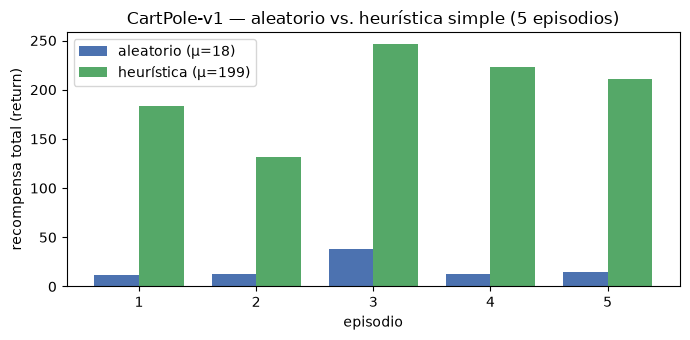

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(N_EP_CMP); w = 0.38
ax.bar(x - w/2, cp_rand5_ret, w, label=f"aleatorio (μ={cp_rand5_ret.mean():.0f})", color="#4C72B0")
ax.bar(x + w/2, cp_heur5_ret, w, label=f"heurística (μ={cp_heur5_ret.mean():.0f})", color="#55A868")
ax.set_xlabel("episodio"); ax.set_ylabel("recompensa total (return)")
ax.set_title("CartPole-v1 — aleatorio vs. heurística simple (5 episodios)")
ax.set_xticks(x); ax.set_xticklabels(range(1, N_EP_CMP + 1)); ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "cartpole_random_vs_heuristic.png", dpi=130)
plt.show()

La política heurística —una sola regla sobre el signo de la velocidad angular
del poste, sin aprendizaje— multiplica varias veces la recompensa media del
agente aleatorio en CartPole-v1. Corrige activamente hacia donde el poste se
cae, mientras que el agente aleatorio la mitad de las veces empuja en la
dirección equivocada. Aun así no llega al máximo de 500: la regla ignora la
posición del carro, que termina saliéndose de los límites, y no anticipa (solo
reacciona al signo). El análisis completo está en la sección 4 del reporte.